<a href="https://colab.research.google.com/github/luisy-eng/ECE491E_Lab1/blob/main/Task%204/Task4_MSELoss.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 4: Customize Loss Function — Mean Squared Error

The purpose of Task 4 is to replace the classification loss function used in
Task 1 with Mean Squared Error (MSE) loss.

The Task 3 model contains a single output neuron, which produces one continuous
value for each CIFAR-10 image. To use this architecture with CIFAR-10, the
integer class labels from 0 through 9 are treated as numerical regression
targets.

This is different from the standard use of CIFAR-10, which is normally treated
as a ten-class classification problem. The regression formulation is used here
to follow the architecture and loss-function requirements of the project.

In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split, ConcatDataset
from torchvision import datasets
from torchvision.transforms import ToTensor, Normalize, Compose
import matplotlib.pyplot as plt

In [2]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(f"Using {device} device")

Using cuda device


In [3]:
transform = Compose([
    ToTensor(),
    Normalize(
        mean=(0.5, 0.5, 0.5),
        std=(0.5, 0.5, 0.5)
    )
])

cifar_train = datasets.CIFAR10(
    root="data",
    train=True,
    download=True,
    transform=transform
)

cifar_test = datasets.CIFAR10(
    root="data",
    train=False,
    download=True,
    transform=transform
)

full_dataset = ConcatDataset([
    cifar_train,
    cifar_test
])

train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size

train_data, test_data = random_split(
    full_dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

batch_size = 64

train_dataloader = DataLoader(
    train_data,
    batch_size=batch_size,
    shuffle=True
)

test_dataloader = DataLoader(
    test_data,
    batch_size=batch_size,
    shuffle=False
)

100%|██████████| 170M/170M [25:34<00:00, 111kB/s]


In [4]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten()

        self.network = nn.Sequential(
            nn.Linear(3072, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.network(x)


model = NeuralNetwork().to(device)

print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=3072, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)


## Mean Squared Error Loss

Task 1 used `CrossEntropyLoss` because FashionMNIST was treated as a
multi-class classification problem.

For Task 4, the loss function is changed to Mean Squared Error:

\[
\mathrm{MSE} =
\frac{1}{N}
\sum_{i=1}^{N}
(y_i-\hat{y}_i)^2
\]

where \(y_i\) is the numerical target label and \(\hat{y}_i\) is the model's
continuous prediction.

Because `MSELoss` compares floating-point values, the CIFAR-10 labels must be
converted from integer tensors to floating-point tensors before calculating
the loss.

In [5]:
loss_fn = nn.MSELoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=1e-3
)

print(loss_fn)
print(optimizer)

MSELoss()
SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)


In [6]:
def train_loop(dataloader, model, loss_fn, optimizer):
    model.train()

    running_loss = 0.0

    for images, labels in dataloader:
        images = images.to(device)

        # Convert integer class labels into float regression targets
        labels = labels.float().to(device).unsqueeze(1)

        predictions = model(images)

        loss = loss_fn(predictions, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(dataloader)

In [7]:
def test_loop(dataloader, model, loss_fn):
    model.eval()

    running_loss = 0.0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.float().to(device).unsqueeze(1)

            predictions = model(images)

            loss = loss_fn(predictions, labels)

            running_loss += loss.item()

    return running_loss / len(dataloader)

In [8]:
epochs = 10

train_losses = []
test_losses = []

for epoch in range(epochs):

    train_loss = train_loop(
        train_dataloader,
        model,
        loss_fn,
        optimizer
    )

    test_loss = test_loop(
        test_dataloader,
        model,
        loss_fn
    )

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Test Loss: {test_loss:.6f}"
    )

Epoch 1/10 | Train Loss: 9.221878 | Test Loss: 7.504057
Epoch 2/10 | Train Loss: 7.627019 | Test Loss: 7.205754
Epoch 3/10 | Train Loss: 7.332627 | Test Loss: 7.133181
Epoch 4/10 | Train Loss: 7.184160 | Test Loss: 7.024420
Epoch 5/10 | Train Loss: 7.045232 | Test Loss: 6.905049
Epoch 6/10 | Train Loss: 6.939080 | Test Loss: 6.848081
Epoch 7/10 | Train Loss: 6.847244 | Test Loss: 6.791628
Epoch 8/10 | Train Loss: 6.805724 | Test Loss: 6.761819
Epoch 9/10 | Train Loss: 6.707950 | Test Loss: 6.702089
Epoch 10/10 | Train Loss: 6.627063 | Test Loss: 6.663068


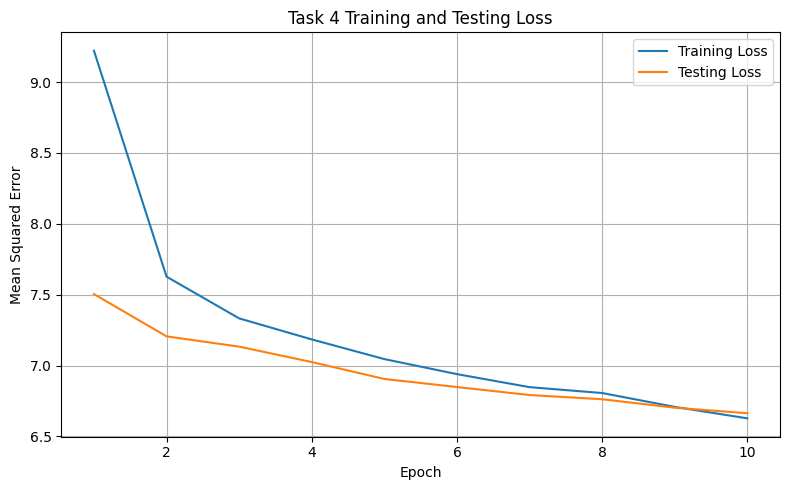

In [9]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    train_losses,
    label="Training Loss"
)

plt.plot(
    range(1, epochs + 1),
    test_losses,
    label="Testing Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("Task 4 Training and Testing Loss")
plt.legend()
plt.grid()

plt.tight_layout()

plt.savefig(
    "training_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Training Result Interpretation

Both the training and testing MSE decreased over the 10 training epochs,
indicating that the model learned to reduce the numerical error between its
continuous outputs and the CIFAR-10 class indices.

The final training MSE was approximately 6.63 and the final testing MSE was
approximately 6.66. The similar final values suggest that the model did not
show a large train-test divergence during this experiment.

However, these MSE values should not be interpreted in the same way as
classification accuracy. Because CIFAR-10 class labels are categorical rather
than naturally ordered numerical values, treating the labels 0 through 9 as
regression targets imposes an artificial numerical relationship between the
classes.

## Regression Prediction Demonstration

Although the model produces a continuous regression output, CIFAR-10 targets
are integer labels from 0 through 9.

For interpretation, the continuous prediction can be rounded to the nearest
integer and limited to the valid label range from 0 to 9. This rounded value is
used only for displaying the result; training continues to use the original
continuous model output.

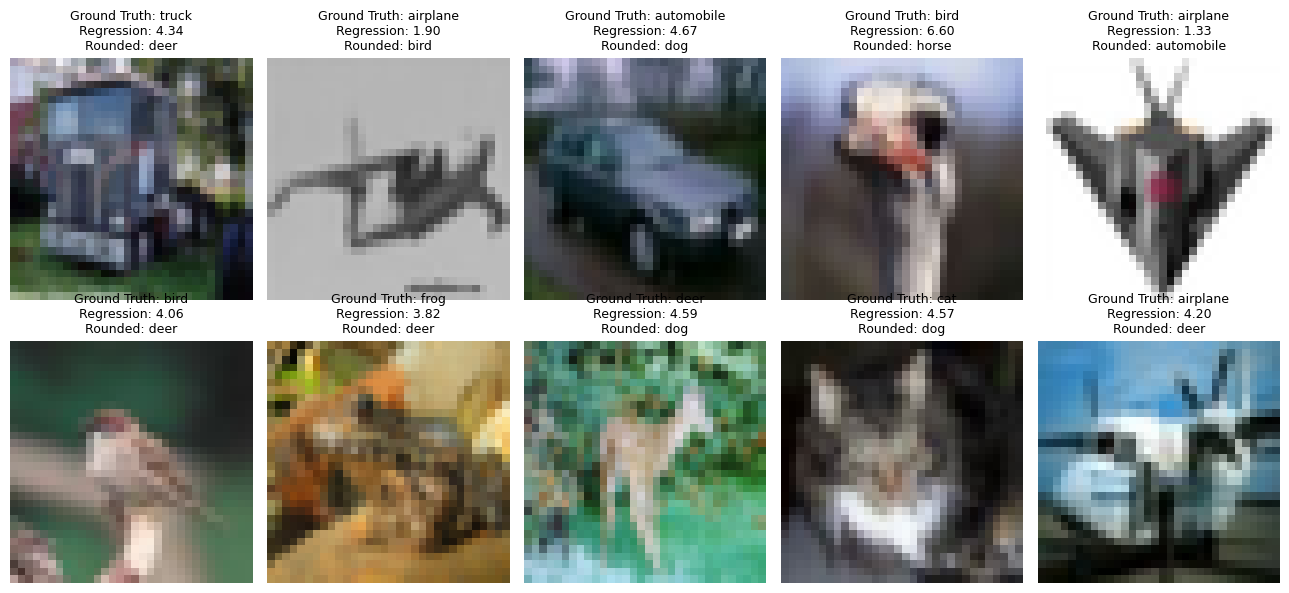

In [10]:
classes = (
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
)

model.eval()

images, labels = next(iter(test_dataloader))

images = images.to(device)

with torch.no_grad():
    predictions = model(images).squeeze(1)

images = images.cpu()
predictions = predictions.cpu()

fig, axes = plt.subplots(2, 5, figsize=(13, 6))

for i, ax in enumerate(axes.flat):

    image = images[i] * 0.5 + 0.5
    image = image.permute(1, 2, 0)

    continuous_prediction = predictions[i].item()

    rounded_prediction = round(continuous_prediction)
    rounded_prediction = max(0, min(9, rounded_prediction))

    true_label = labels[i].item()

    ax.imshow(image)

    ax.set_title(
        f"Ground Truth: {classes[true_label]}\n"
        f"Regression: {continuous_prediction:.2f}\n"
        f"Rounded: {classes[rounded_prediction]}",
        fontsize=9
    )

    ax.axis("off")

plt.tight_layout()

plt.savefig(
    "Task4_predictions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Task 4 Summary

Task 4 replaced the `CrossEntropyLoss` used in the original classification
tutorial with `MSELoss`.

The CIFAR-10 class indices from 0 through 9 were treated as numerical
regression targets to match the required single-output architecture.

The completed experiment therefore combines:

- The normalized CIFAR-10 dataset from Task 2.
- The `3072 → 128 → 64 → 1` network from Task 3.
- ReLU activation after each hidden layer.
- Dropout with probability 0.3.
- Mean Squared Error loss.
- SGD optimization with a learning rate of 0.001.

Training and testing loss were recorded across 10 epochs and visualized to
evaluate the behavior of the regression model.